```{index} single: application; shortest path
```
```{index} networkx
```
```{index} network optimization
```
```{index} pandas dataframe
```

# Extra material: Shortest path problem in real life

In [1]:
import os
import sys
import subprocess

try:
    import google.colab
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q",
        "pandana==0.8", "osmnx", "geopy", "folium", "matplotlib",
        "scikit-learn", "psutil", "mapclassify", "threadpoolctl",
    ])

# Set before importing Pandana, so OpenMP initializes with one worker.
# Deliberately compare both routing implementations without parallel speedup.
PANDANA_THREADS = 1
os.environ["OMP_NUM_THREADS"] = str(PANDANA_THREADS)
os.environ["OMP_DYNAMIC"] = "FALSE"

import gc
import zipfile
from numbers import Number
import hashlib
import json
import platform
from datetime import datetime, timezone
from importlib.metadata import version
from pathlib import Path
from time import perf_counter

import folium
import geopy
from geopy.extra.rate_limiter import RateLimiter
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import osmnx as ox
import pandas as pd
import pandana
import psutil
from threadpoolctl import threadpool_info
from IPython.display import display, FileLink
from packaging.version import Version

assert Version(version("pandana")) >= Version("0.8"), "Please upgrade Pandana."
pd.options.display.float_format = "{:.3f}".format
evidence = Path("data") / "shortest-path-live"
evidence.mkdir(parents=True, exist_ok=True)

openmp_pools = [p for p in threadpool_info() if p["user_api"] == "openmp"]
assert openmp_pools and all(p["num_threads"] == 1 for p in openmp_pools)

def style_table(table):
    """Align text left and numbers right, including row and column headings."""
    def alignment(value):
        return "text-align: right" if isinstance(value, Number) else "text-align: left"

    styles = [
        {"selector": f"th.col_heading.col{i}",
         "props": [("text-align", "right" if pd.api.types.is_numeric_dtype(table[column])
                    else "left")]}
        for i, column in enumerate(table.columns)
    ]
    return (table.style.map(alignment)
            .map_index(alignment, axis=0)
            .set_table_styles(styles))


## Introduction

Google Maps brought the world to our screens, including geocoding and routing for
several modes of transport. Much of its use is interactive, but data and analytics
applications also need programmatic access to these services. Here we use open
tools to geocode places and find walking routes in Amsterdam.

The main question is how to compute many shortest paths efficiently. We begin
with individual routes, then compare a distance matrix computed row by row with
one-to-many Dijkstra searches against a single batched Pandana call. Pandana uses
contraction hierarchies to preprocess the network for repeated queries.

For local execution install `pandana>=0.8`, `osmnx`, `geopy`, `folium`,
`matplotlib`, `scikit-learn`, `mapclassify`, `psutil`, and `threadpoolctl`. Colab installation is handled above.
Geocoding, map acquisition, and interactive background tiles require internet access.

### Running and saving in Google Colab

Open this notebook in Colab with a fresh **CPU runtime**, then choose **Runtime >
Run all**. The first cell installs Pandana 0.8 and the required packages. The
Amsterdam graph and geocoding responses are acquired live, so results can change
with map updates. The benchmark records the graph checksum, sampled nodes,
installed versions and the actual runtime CPU and memory. The standard NetworkX
Dijkstra implementation used here is single-threaded, and we process origins
sequentially. We deliberately restrict **Pandana to one thread** to showcase the
difference between repeated Dijkstra searches and preprocessed
contraction-hierarchy queries without a parallel speedup advantage.
NetworkX uses Python and Pandana's routing engine uses C++, so language and
implementation overhead also contribute; this is not a language-controlled test.
This describes the standard NetworkX routine used in this notebook, not a
limitation of every [NetworkX backend](https://networkx.org/documentation/stable/backends.html).

`PANDANA_THREADS` sets `OMP_NUM_THREADS` **before Pandana is imported**, controlling
the OpenMP workers used for construction and batched queries. Here it is fixed at
**1** throughout. `OMP_DYNAMIC=FALSE` disables dynamic adjustment, and the notebook
checks the loaded OpenMP runtime. Restart the runtime before rerunning the setup
cell if Pandana was already imported with another thread setting.

This single-thread setting is a deliberate choice for the comparison, not a
recommendation for deployment. In your own application, allowing Pandana to use
multiple threads may further reduce construction and batched-query times,
depending on the workload and available CPU cores. Practical performance may
therefore improve beyond the single-thread results shown here; benchmark the
thread count on your target machine rather than assuming proportional speedup.

The final export cell downloads an archive of this session's timing records and
environment. Also use **File > Download > Download .ipynb** to keep the notebook
with its rendered outputs; leave **Omit code cell output when saving** disabled.
Runtime files alone are temporary. See the [Colab FAQ](https://research.google.com/colaboratory/faq.html).
The national results remain explicitly labelled as previously measured Windows
results; running Colab does not turn them into Colab measurements.


## Some background information and history

[Geoff Boeing](https://geoffboeing.com/) has made urban data analytics more
accessible, particularly the analysis of street networks. His
[research](https://geoffboeing.com/research/) is accompanied by usable demonstrations
with [OSMnx](https://osmnx.readthedocs.io/en/stable/).

Professor [Peter Sanders](https://ae.iti.kit.edu/sanders.php) and his collaborators'
[route-planning research](https://ae.iti.kit.edu/routeplanning.php) helped make exact
shortest-path queries practical on very large road networks. Two contributors
worth highlighting are:

* **[Dominik Schultes](https://turing.iem.thm.de/routeplanning/)**, whose work with Sanders on highway hierarchies helped
  exploit the hierarchical structure of road networks. The subsequent work on
  [contraction hierarchies](https://ae.iti.kit.edu/1129.php), with [Robert Geisberger](https://research.google/people/author39325/)
  and [Daniel Delling](https://www.danieldelling.com/), made preprocessing simpler while keeping queries fast.
  Exact shortest-path algorithms already existed; the advance was their practical
  scalability for repeated queries on large road networks. For historical context, see
  the [DIMACS shortest-path challenge](https://www.diag.uniroma1.it/challenge9/)
  and the [Scientific American 50 feature](https://www.scientificamerican.com/article/sciam-50-the-fastest-way/)
  discussing Schultes and transit-node routing.
* **[Dennis Luxen](https://ae.iti.kit.edu/english/luxen.php)**, a creator of the [Open Source Routing Machine
  (OSRM)](https://github.com/Project-OSRM/osrm-backend), which makes scalable road
  routing available as open-source software.

[Pandana originated](https://github.com/UDST/pandana/blob/main/HISTORY.md) in
research led by **[Paul Waddell](https://ced.berkeley.edu/people/paul-waddell)** at the University of California, Berkeley, on
land use, transportation, and accessibility. Waddell conceived the application
with **[Fletcher Foti](https://github.com/fscottfoti)**, his doctoral student, and **[Dennis Luxen](https://ae.iti.kit.edu/english/luxen.php)**, and provided
research direction and funding. Foti led the original software implementation
and its pandas-oriented interface; Luxen contributed routing expertise and
contraction-hierarchy code. Their
[2012 paper](https://onlinepubs.trb.org/onlinepubs/conferences/2012/4thITM/Papers-A/0117-000062.pdf)
describes how the framework connects parcels and complete street networks for
accessibility analysis from pedestrian to metropolitan scales.

Pandana subsequently became part of the **Urban Data Science Toolkit (UDST)**,
with contributions from [Matt Davis](https://github.com/jiffyclub), [Federico Fernandez](https://github.com/federicofernandez), [Sam Maurer](https://github.com/smmaurer), and the
wider community.

[Pandana 0.8](https://github.com/UDST/pandana/releases/tag/v0.8), released in
August 2026, reflects a collective effort to support the modern Python ecosystem.
**[Paul Waddell](https://ced.berkeley.edu/people/paul-waddell)** helped coordinate the renewed maintenance work, and **[Sam Maurer](https://github.com/smmaurer)**
helped bring the release to completion. Among the wider community of contributors,
**[Joaquim Gromicho](https://github.com/UDST/pandana/pull/198)** contributed
compatibility updates supporting Python 3.14, NumPy 2, and pandas 3.
This contribution was part of the collective maintenance and release effort.

The key idea of contraction hierarchies is to remove nodes in a preprocessing
order, adding shortcuts where needed to preserve shortest-path distances.
Queries can then search the hierarchy rather than explore the full network.
Preprocessing takes time and memory, but its cost can be shared across many queries.
The experiment at the end examines this tradeoff.

## Geocoding and map visualization

The world is mapped with the [geographic coordinate system](https://en.wikipedia.org/wiki/Geographic_coordinate_system) but we have difficulties remembering [latitudes]( https://en.wikipedia.org/wiki/Latitude) and [longitudes]( https://en.wikipedia.org/wiki/Longitude). We learn and remember the world better from addresses.

In [2]:
locator = geopy.Photon(user_agent="MO-book-shortest-path-example", timeout=30)
geocode = RateLimiter(locator.geocode, min_delay_seconds=1, max_retries=2,
                      error_wait_seconds=3, swallow_exceptions=False)

def locate_geopy(description):
    location = geocode(description)
    if location is None:
        raise ValueError(f"No geocoding result for {description!r}")
    return location

data = {
    "address": ["Centraal Station", "VU Hoofdgebouw", "Amsterdam Business School",
                "University of Amsterdam", "Johan Cruijff ArenA", "Ziggo Dome"],
    "color": ["blue", "black", "orange", "green", "red", "purple"],
}
df = pd.DataFrame(data)
df["city"], df["country"] = "Amsterdam", "NL"
locations = [locate_geopy(", ".join(row[["address", "city", "country"]]))
             for _, row in df.iterrows()]
df["lat"] = [loc.latitude for loc in locations]
df["lon"] = [loc.longitude for loc in locations]
display(style_table(df).format({"lat": "{:.6f}", "lon": "{:.6f}"}))
geocoding_record = {
    "retrieved_utc": datetime.now(timezone.utc).isoformat(),
    "provider": "Photon", "results": [loc.raw for loc in locations],
}
(evidence / "geocoding.json").write_text(json.dumps(geocoding_record, indent=2), encoding="utf-8")

Amsterdam = locate_geopy("Amsterdam, NL")
Map = folium.Map(location=(Amsterdam.latitude, Amsterdam.longitude), zoom_start=13)
for _, row in df.iterrows():
    folium.Marker((row.lat, row.lon), icon=folium.Icon(color=row.color),
                  tooltip=row.address).add_to(Map)
Map

,address,color,city,country,lat,lon
0,Centraal Station,blue,Amsterdam,NL,52.379045,4.900871
1,VU Hoofdgebouw,black,Amsterdam,NL,52.334180,4.866900
2,Amsterdam Business School,orange,Amsterdam,NL,52.365107,4.911718
3,University of Amsterdam,green,Amsterdam,NL,52.368133,4.889804
4,Johan Cruijff ArenA,red,Amsterdam,NL,52.314353,4.942843
5,Ziggo Dome,purple,Amsterdam,NL,52.313753,4.937709


Geocoding returns coordinates for a description, not necessarily the entrance we
had in mind. Inspect the map and the returned locations. Responses can change
over time; this run saves the responses for reference, but executes live geocoding.

In [3]:
ox.settings.log_console = False
ox.settings.use_cache = True
ox.settings.cache_folder = evidence / ".cache"

In [4]:
# Keep the original Amsterdam walking-network example.
G_walk = ox.graph_from_place("Amsterdam, NL", network_type="walk")
ox.save_graphml(G_walk, evidence / "amsterdam-walk.graphml.gz")
print(f"G_walk has {G_walk.number_of_nodes():,} nodes and {G_walk.number_of_edges():,} arcs.")

G_walk has 51,795 nodes and 143,968 arcs.


The graph comes from [OpenStreetMap contributors](https://www.openstreetmap.org/copyright)
(ODbL). Its municipal boundary and retained connected component can affect
coverage. A route is shortest within this graph; it is not a guarantee about
temporary closures or walking access at a venue.

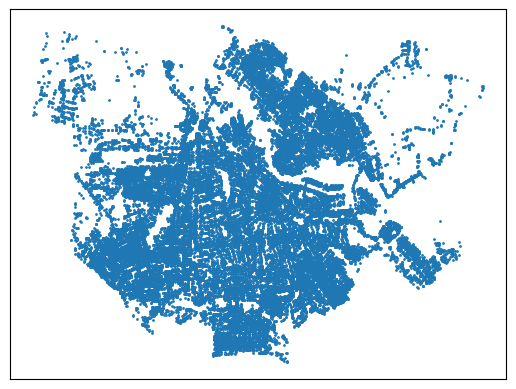

In [5]:
# Visualize the graph
node_positions = {
    node: (data["x"], data["y"]) for node, data in G_walk.nodes(data=True)
}
nx.draw_networkx_nodes(G_walk, pos=node_positions, node_size=1)
plt.show()

In [6]:
def style_locations(table):
    return style_table(table).format({"lat": "{:.6f}", "lon": "{:.6f}",
                                      "node": "{:.0f}", "snap_m": "{:.3f}"})

df["node"], df["snap_m"] = ox.distance.nearest_nodes(
    G_walk, df.lon, df.lat, return_dist=True
)
display(style_locations(df[["address", "lat", "lon", "node", "snap_m"]]))
shared = df[df.duplicated("node", keep=False)]
if not shared.empty:
    print("Distinct places assigned to the same graph node:")
    display(style_locations(shared[["address", "node", "snap_m"]]))

,address,lat,lon,node,snap_m
0,Centraal Station,52.379045,4.900871,5629071965,11.179
1,VU Hoofdgebouw,52.334180,4.866900,294648098,61.952
2,Amsterdam Business School,52.365107,4.911718,46356661,43.880
3,University of Amsterdam,52.368133,4.889804,13285036240,55.953
4,Johan Cruijff ArenA,52.314353,4.942843,2680554148,2329.508
5,Ziggo Dome,52.313753,4.937709,2680554148,2016.547


Distinct places assigned to the same graph node:


,address,node,snap_m
4,Johan Cruijff ArenA,2680554148,2329.508
5,Ziggo Dome,2680554148,2016.547


### Different places can share a snapped node

The earlier saved example gave ArenA and Ziggo Dome **different coordinates**,
but assigned both to the same graph node. These are separate steps: geocoding
locates the place, while snapping chooses a node in the available network.
Shared nodes give identical network-distance rows and zero distance between the
assigned nodes. This does not mean the venues coincide. Large snapping distances
can also reveal missing network coverage near the original coordinates.

We keep this example and display the snapping distances. The occurrence of a
shared node may change with live data. Both routing packages below reuse the
same node assignment so that they solve the same query.

In the route map, blue lines follow road edges; dashed magenta lines connect
the geocoded places to their snapped nodes. These straight-line connectors
show the snapping offsets, not verified walkable access routes.


In [7]:
# Reduce parallel arcs by minimum length, preserving all existing directions.
G = ox.convert.to_digraph(G_walk, weight="length")
route = nx.shortest_path(G, df.loc[0, "node"], df.loc[1, "node"], weight="length")
print(f"Centraal Station to VU: {nx.path_weight(G, route, 'length') / 1000:.3f} km")

Centraal Station to VU: 6.876 km


In [8]:
# Draw road edges and straight-line snapping connectors separately.
def draw_route(path, places=None):
    route_edges = ox.routing.route_to_gdf(G_walk, path, weight="length")
    route_map = route_edges.explore(
        tiles="OpenStreetMap", color="#176a8a", style_kwds={"weight": 5}
    )
    bounds = [[G_walk.nodes[node]["y"], G_walk.nodes[node]["x"]] for node in path]
    if places is not None:
        for _, place in places.iterrows():
            point = [place.lat, place.lon]
            snapped = [G_walk.nodes[place.node]["y"], G_walk.nodes[place.node]["x"]]
            folium.PolyLine(
                [point, snapped], color="#d33682", weight=5, dash_array="8, 6",
                tooltip=f"{place.address}: snapping segment ({place.snap_m:.1f} m); straight-line estimate",
            ).add_to(route_map)
            folium.Marker(point, tooltip=place.address).add_to(route_map)
            folium.CircleMarker(snapped, radius=4, color="#d33682", fill=True,
                                tooltip="Snapped road node").add_to(route_map)
            bounds.append(point)
    legend = '<div style="position:fixed;bottom:25px;left:25px;z-index:9999;background:white;padding:10px;border:1px solid gray">'
    legend += '<span style="color:#176a8a">&#9473;&#9473;</span> Road route'
    if places is not None:
        legend += '<br><span style="color:#d33682">- - -</span> Snapping segment (straight-line estimate)'
    else:
        legend += '<br>Endpoints are sampled road nodes; no snapping segments.'
    route_map.get_root().html.add_child(folium.Element(legend + '</div>'))
    route_map.fit_bounds(bounds)
    return route_map

draw_route(route, df.loc[[0, 1]])

## Shortest paths and contraction hierarchies

The routing problem is a weighted shortest-path problem. Let $G=(V,A)$ be the
walking network, with nonnegative arc lengths $\ell_{uv}$. For snapped origin
$s$ and destination $t$, let $\mathcal P_{st}$ contain the paths from $s$ to $t$
that follow the allowed arcs and their directions. We seek

$$
d(s,t)=\min_{P\in\mathcal P_{st}}\sum_{(u,v)\in P}\ell_{uv}.
$$

A feasible route stays on the supplied walking network and respects its allowed
directions; if no such path exists, the destination is unreachable. Repeating
this problem for each selected origin and destination gives the distance matrix.
The snapping segments are outside this network objective; the access-distance
extension below treats them separately. The timing experiment uses mutually
reachable nodes and identical integer-millimetre arc costs for both implementations.

For a single route Dijkstra's algorithm is straightforward. For many routes,
Pandana invests in contraction-hierarchy preprocessing. We record that cost
separately from the subsequent queries. The walking graph already contains its
allowed directions, so `twoway=False` avoids adding new reverse arcs.

In [9]:
construction_start = perf_counter()
nodes = pd.DataFrame.from_dict(dict(G.nodes(data=True)), orient="index")
edges = nx.to_pandas_edgelist(G)
network_start = perf_counter()
network = pandana.Network(nodes["x"], nodes["y"], edges["source"], edges["target"],
                          edges[["length"]], twoway=False)
network_construction_s = perf_counter() - network_start
preprocessing_s = perf_counter() - construction_start
print(f"DataFrame preparation + network construction: {preprocessing_s:.3f} s")
print(f"Network constructor (including hierarchy): {network_construction_s:.3f} s")

DataFrame preparation + network construction: 2.603 s
Network constructor (including hierarchy): 1.704 s


In [10]:
df["pandana"] = df["node"]
display(style_table(df[["address", "node", "pandana", "snap_m"]]))

,address,node,pandana,snap_m
0,Centraal Station,5629071965,5629071965,11.179360
1,VU Hoofdgebouw,294648098,294648098,61.952308
2,Amsterdam Business School,46356661,46356661,43.879517
3,University of Amsterdam,13285036240,13285036240,55.952679
4,Johan Cruijff ArenA,2680554148,2680554148,2329.507539
5,Ziggo Dome,2680554148,2680554148,2016.546853


In [11]:
origin, destination = df.loc[2, "node"], df.loc[3, "node"]
path_pandana = list(network.shortest_path(origin, destination))
path_nx = nx.shortest_path(G, origin, destination, weight="length")

Two optimal routes need not visit identical nodes. Check their endpoints, arcs,
and costs rather than the set difference of their nodes. Pandana represents costs
as integer thousandths of the supplied unit: here it truncates each arc to whole
millimetres. For exact comparison we give NetworkX those same integer costs.
This numerical convention does not imply millimetre accuracy of the map.

In [12]:
for _, _, attributes in G.edges(data=True):
    attributes["length_mm"] = int(attributes["length"] * 1000)
assert path_pandana[0] == origin and path_pandana[-1] == destination
assert all(G.has_edge(u, v) for u, v in zip(path_pandana[:-1], path_pandana[1:]))
reference = nx.shortest_path_length(G, origin, destination, weight="length_mm") / 1000
assert np.isclose(nx.path_weight(G, path_pandana, "length_mm") / 1000,
                  reference, atol=1e-6, rtol=0)
print(f"NetworkX, original lengths: {nx.path_weight(G, path_nx, 'length'):.3f} m")
print(f"Pandana, integer-mm costs: {network.shortest_path_length(origin, destination):.3f} m")

NetworkX, original lengths: 1883.315 m
Pandana, integer-mm costs: 1883.298 m


In [13]:
ids = df.node.to_numpy(dtype=np.int64)
origs = np.repeat(ids, len(ids))
dests = np.tile(ids, len(ids))
distances = np.asarray(network.shortest_path_lengths(origs, dests)).reshape(len(ids), len(ids))
display(style_table(pd.DataFrame(distances, index=df.address.copy(), columns=df.address.copy()).rename_axis(index=None, columns=None).round(1)).format("{:.1f}"))

,Centraal Station,VU Hoofdgebouw,Amsterdam Business School,University of Amsterdam,Johan Cruijff ArenA,Ziggo Dome
Centraal Station,0.0,6876.2,2288.7,1588.8,8689.6,8689.6
VU Hoofdgebouw,6876.2,0.0,6208.5,5425.1,7564.6,7564.6
Amsterdam Business School,2288.7,6208.5,0.0,1883.3,7376.6,7376.6
University of Amsterdam,1588.8,5425.1,1883.3,0.0,7543.5,7543.5
Johan Cruijff ArenA,8689.6,7564.6,7376.6,7543.5,0.0,0.0
Ziggo Dome,8689.6,7564.6,7376.6,7543.5,0.0,0.0


### An access-distance extension

One simple estimate adds the two straight-line snapping distances to the network
distance: $\widehat d_{ij}=s_i+d_{ij}^{\mathrm{network}}+s_j$ for distinct places.
The distance from a place to itself remains zero. If two places share a node,
the estimate includes travelling from each point to that common node.

These connectors are not verified walkable paths and can cross barriers. The
estimate need not be the shortest real-world route, especially when the graph
omits nearby streets. Comparing the two tables makes the effect of snapping
visible rather than hiding it by replacing the example locations.

In [14]:
access_estimate = distances + df.snap_m.to_numpy()[:, None] + df.snap_m.to_numpy()[None, :]
np.fill_diagonal(access_estimate, 0)
display(style_table(pd.DataFrame(access_estimate, index=df.address.copy(), columns=df.address.copy()).rename_axis(index=None, columns=None).round(1)).format("{:.1f}"))

,Centraal Station,VU Hoofdgebouw,Amsterdam Business School,University of Amsterdam,Johan Cruijff ArenA,Ziggo Dome
Centraal Station,0.0,6949.3,2343.7,1655.9,11030.3,10717.4
VU Hoofdgebouw,6949.3,0.0,6314.3,5543.0,9956.1,9643.1
Amsterdam Business School,2343.7,6314.3,0.0,1983.1,9750.0,9437.1
University of Amsterdam,1655.9,5543.0,1983.1,0.0,9928.9,9616.0
Johan Cruijff ArenA,11030.3,9956.1,9750.0,9928.9,0.0,4346.1
Ziggo Dome,10717.4,9643.1,9437.1,9616.0,4346.1,0.0


### A batch of routes

We first demonstrate a matrix for 50 sampled nodes. Sampling within one strongly
connected component ensures that all selected pairs are reachable. Later we
increase the matrix size systematically. Retrieve only a few full paths here;
storing every path requires much more memory than storing the distance matrix.

In [15]:
component = np.array(sorted(max(nx.strongly_connected_components(G), key=len)), dtype=np.int64)
rng = np.random.default_rng(2025)
sample = rng.choice(component, min(50, len(component)), replace=False)
origs, dests = np.repeat(sample, len(sample)), np.tile(sample, len(sample))
table = pd.DataFrame(np.asarray(network.shortest_path_lengths(origs, dests)).reshape(len(sample), -1),
                     index=sample, columns=sample)
departure, arrival = np.unravel_index(np.argmax(table.to_numpy()), table.shape)
path_pandana = list(network.shortest_path(sample[departure], sample[arrival]))
print(f"Largest distance in this sample: {table.iloc[departure, arrival] / 1000:.3f} km")
paths = network.shortest_paths(origs[:5], dests[:5])

Largest distance in this sample: 24.141 km


In [16]:
street_names = []
for u, v in zip(paths[1][:-1], paths[1][1:]):
    name = G[u][v].get("name", "Unnamed path")
    if isinstance(name, list):
        name = " / ".join(map(str, name))
    if not street_names or name != street_names[-1]:
        street_names.append(name)
print(" → ".join(street_names[:20]))
if len(street_names) > 20:
    print(f"... {len(street_names) - 20} further named segments")

Unnamed path → Bornhout → Australiëhavenweg → Westpoortweg → Luvernes → Unnamed path → Sierenborch → Theemsweg → Seineweg → Naritaweg → Seineweg → Burgemeester De Vlugtlaan → Unnamed path → Burgemeester De Vlugtlaan → Bos en Lommerweg / Burgemeester De Vlugtlaan → Bos en Lommerweg → Bos en Lommerplein → Unnamed path → Hoofdweg → Unnamed path
... 31 further named segments


In [17]:
# These sampled endpoints already lie on the road network.
draw_route(paths[1])

## How does the distance-matrix computation scale?

The next cell records the machine and software for the **current execution**,
including its CPU allocation. Colab hardware varies between sessions. The saved Amsterdam outputs in
this local revision were measured on 24 September 2026 on an Intel Core Ultra 9
285HX, 24 cores / 24 logical processors, 63.46 GiB RAM, 64-bit Windows 11 build
26200, Python 3.14.6, Pandana 0.8, NetworkX 3.6.1, NumPy 2.5.3, pandas 3.0.5 and
OSMnx 2.1.1. A completed Colab execution must replace these outputs and retain
its own environment record; Windows measurements must not be relabelled as Colab.
CPU affinity, power/frequency settings and background activity are not controlled.

The saved Amsterdam walking snapshot has **51,795 nodes** and **142,338 directed arcs**
after keeping the shortest of parallel arcs (143,968 arcs before reduction).
For a live download, use the graph counts printed by that execution.
For each size $n$, all methods compute the same $n\times n$ matrix. NetworkX runs
one **single-source Dijkstra search per origin**, exploring the reachable graph
and then extracting the selected destinations. Pandana receives all $n^2$
ordered pairs in one batch call. NetworkX's standard Dijkstra routine is
single-threaded, and our loop processes one origin at a time. We deliberately
restrict **Pandana's construction and queries to one thread**. The purpose is to
showcase the different algorithmic implementations without parallelism as an
additional source of speedup. The Python/C++ language difference remains.

Nested samples use seed 2025 and sizes 10, 25, 50, 100, 250, 500, and 1000.
Each method has one warm-up and three measured repetitions per size. The order
alternates across repetitions. Query wall time includes query-array preparation,
distance computation, matrix conversion and temporary-object cleanup. Graph
loading, hierarchy preprocessing, validation and plotting are excluded.
Preprocessing is recorded separately, once. All methods use
the same integer-millimetre arc costs; every matrix is checked outside the timer.

NetworkX uses one sequential Python worker; Pandana also uses compiled C++.
Even the single-thread comparison therefore measures these implementations,
not the algorithmic effect of contraction hierarchies in isolation. The sampling
pool is fixed independently of the tested sizes; no matrix exceeds 1,000 locations.

In [18]:
hardware = {
    "cpu": platform.processor() or "unavailable",
    "physical_cores": psutil.cpu_count(logical=False),
    "logical_processors": psutil.cpu_count(logical=True),
    "ram_GiB": round(psutil.virtual_memory().total / 2**30, 2),
    "os": platform.platform(), "architecture": platform.machine(),
}
if platform.system() == "Windows":
    hardware["cpu"] = subprocess.check_output([
        "powershell.exe", "-NoProfile", "-Command",
        "(Get-CimInstance Win32_Processor).Name",
    ], text=True).strip()
if platform.system() == "Linux" and Path("/proc/cpuinfo").exists():
    for line in Path("/proc/cpuinfo").read_text().splitlines():
        if line.startswith("model name"):
            hardware["cpu"] = line.split(":", 1)[1].strip()
            break
try:
    affinity_cpus = len(os.sched_getaffinity(0))
except AttributeError:
    affinity_cpus = len(psutil.Process().cpu_affinity()) if hasattr(psutil.Process(), "cpu_affinity") else psutil.cpu_count()
cpu_quota = None
quota_file = Path("/sys/fs/cgroup/cpu.max")
if quota_file.exists():
    quota, period = quota_file.read_text().split()
    if quota != "max":
        cpu_quota = int(quota) / int(period)
hardware["CPUs_available_by_affinity"] = affinity_cpus
hardware["cgroup_CPU_quota"] = cpu_quota
hardware["runtime_interface"] = "Google Colab" if IN_COLAB else "Local Python"
hardware["Colab_release_tag"] = os.environ.get("COLAB_RELEASE_TAG", "not reported")
environment = {
    **hardware, "python": platform.python_version(),
    "packages": {p: version(p) for p in ["pandana", "networkx", "numpy", "pandas", "osmnx"]},
    "pandana_OpenMP_threads": PANDANA_THREADS, "NetworkX_workers": 1,
    "seed": 2025, "repetitions": 3, "warmups_per_size": 1,
    "network_nodes": len(G), "directed_arcs": G.number_of_edges(),
    "graph_sha256": hashlib.sha256((evidence / "amsterdam-walk.graphml.gz").read_bytes()).hexdigest(),
    "run_utc": datetime.now(timezone.utc).isoformat(),
    "preprocessing_s": preprocessing_s, "network_constructor_s": network_construction_s,
}
display(style_table(pd.Series({**hardware, "Python": platform.python_version(),
                   "Pandana threads": PANDANA_THREADS,
                   **environment["packages"]}, name="experimental environment").to_frame()))
(evidence / "single-thread-environment.json").write_text(json.dumps(environment, indent=2), encoding="utf-8");

,experimental environment
cpu,Intel(R) Core(TM) Ultra 9 285HX
physical_cores,24
logical_processors,24
ram_GiB,63.460000
os,Windows-11-10.0.26200-SP0
architecture,AMD64
CPUs_available_by_affinity,24
cgroup_CPU_quota,None
runtime_interface,Local Python
Colab_release_tag,not reported


In [19]:
def dijkstra_matrix(selected):
    matrix = np.empty((len(selected), len(selected)), dtype=float)
    for i, origin in enumerate(selected):
        lengths = nx.single_source_dijkstra_path_length(G, int(origin), weight="length_mm")
        matrix[i] = [lengths[int(d)] / 1000 for d in selected]
        del lengths
    return matrix, {}

setup_times = {1: preprocessing_s}

def pandana_matrix(selected):
    start = perf_counter()
    origins = np.repeat(selected, len(selected))
    destinations = np.tile(selected, len(selected))
    prepared = perf_counter()
    values = network.shortest_path_lengths(origins, destinations)
    queried = perf_counter()
    matrix = np.asarray(values).reshape(len(selected), -1)
    converted = perf_counter()
    del values, origins, destinations
    cleaned = perf_counter()
    return matrix, {"arrays_s": prepared-start, "batch_call_s": queried-prepared,
                    "conversion_s": converted-queried, "cleanup_s": cleaned-converted}

sizes = [n for n in [10, 25, 50, 100, 250, 500, 1000] if n <= len(component)]
ordered_sample = np.random.default_rng(2025).choice(
    component, min(5000, len(component)), replace=False)[:max(sizes)]
methods = [("NetworkX (1 thread)", dijkstra_matrix), ("Pandana (1 thread)", pandana_matrix)]
np.save(evidence / "single-thread-selected.npy", ordered_sample)
environment["selected_sha256"] = hashlib.sha256(ordered_sample.tobytes()).hexdigest()
(evidence / "single-thread-environment.json").write_text(json.dumps(environment, indent=2), encoding="utf-8")
measurements = []
for n in sizes:
    selected = ordered_sample[:n]
    expected, _ = dijkstra_matrix(selected)  # NetworkX warm-up and reference
    warmup, _ = pandana_matrix(selected)
    assert np.allclose(warmup, expected, atol=1e-6, rtol=0)
    del warmup
    for repetition in range(3):
        order = methods if repetition % 2 == 0 else methods[::-1]
        for method, function in order:
            pools = [p for p in threadpool_info() if p["user_api"] == "openmp"]
            assert pools and all(p["num_threads"] == 1 for p in pools)
            gc.collect()
            cpu_before = psutil.cpu_percent(interval=0.1)
            start = perf_counter()
            result, phases = function(selected)
            seconds = perf_counter() - start
            error = float(np.max(np.abs(result - expected)))
            assert np.isfinite(result).all() and error <= 1e-6
            measurements.append({"n": n, "method": method, "threads": 1,
                                 "repetition": repetition+1, "seconds": seconds,
                                 "system_cpu_before_pct": cpu_before,
                                 "max_error_m": error, **phases})
            del result
    pd.DataFrame(measurements).to_csv(evidence / "single-thread-repetitions.csv", index=False)
    print(f"Validated {n} x {n}: NetworkX and Pandana, both single-threaded.", flush=True)
    del expected
timings = pd.DataFrame(measurements)
(evidence / "single-thread-setup.json").write_text(json.dumps(setup_times, indent=2));

Validated 10 x 10: NetworkX and Pandana, both single-threaded.


Validated 25 x 25: NetworkX and Pandana, both single-threaded.


Validated 50 x 50: NetworkX and Pandana, both single-threaded.


Validated 100 x 100: NetworkX and Pandana, both single-threaded.


Validated 250 x 250: NetworkX and Pandana, both single-threaded.


Validated 500 x 500: NetworkX and Pandana, both single-threaded.


Validated 1000 x 1000: NetworkX and Pandana, both single-threaded.


method,NetworkX (1 thread),Pandana (1 thread)
n,,
10,0.710,0.010
25,1.821,0.013
50,3.831,0.030
100,7.083,0.094
250,18.818,0.525
500,36.179,2.178
1000,70.799,8.126


,Preprocessing seconds
Pandana threads,
1,2.602846


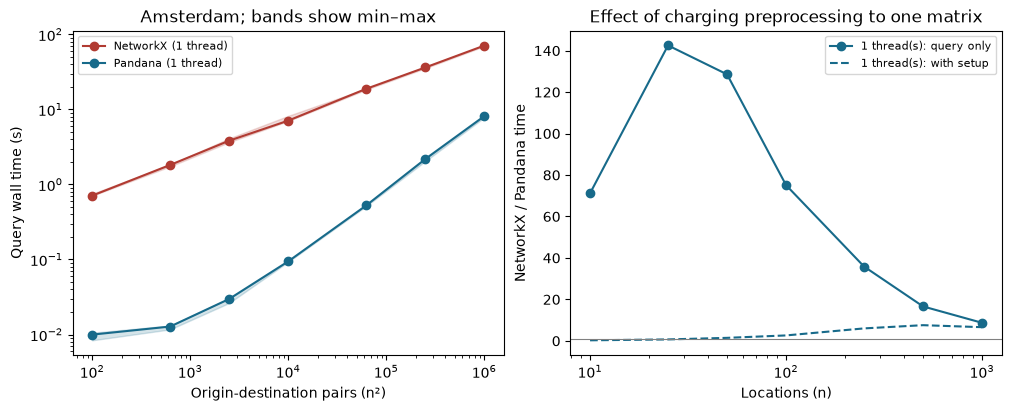

In [20]:
stats = timings.groupby(["n", "method"]).seconds.agg(["median", "min", "max"])
summary = stats["median"].unstack("method")
display(style_table(summary).format("{:.3f}").set_caption("Amsterdam: median query seconds, three repetitions"))
display(style_table(pd.Series(setup_times, name="Preprocessing seconds").rename_axis("Pandana threads").to_frame()))
summary.to_csv(evidence / "single-thread-summary.csv")

fig, axes = plt.subplots(1, 2, figsize=(10, 4), layout="constrained")
for method, color in [("NetworkX (1 thread)", "#b13b32"),
                      ("Pandana (1 thread)", "#176a8a")]:
    values = stats.xs(method, level="method")
    pairs = values.index.to_numpy()**2
    axes[0].plot(pairs, values["median"], "o-", label=method, color=color)
    axes[0].fill_between(pairs, values["min"], values["max"], color=color, alpha=.18)
for threads, color in [(1, "#176a8a")]:
    values = summary[f"Pandana ({threads} thread{'s' if threads > 1 else ''})"]
    axes[1].plot(summary.index, summary["NetworkX (1 thread)"]/values,
                 "o-", color=color, label=f"{threads} thread(s): query only")
    axes[1].plot(summary.index, summary["NetworkX (1 thread)"]/(values+setup_times[threads]),
                 "--", color=color, label=f"{threads} thread(s): with setup")
axes[0].set(xscale="log", yscale="log", xlabel="Origin-destination pairs (n²)",
            ylabel="Query wall time (s)", title="Amsterdam; bands show min–max")
axes[1].set(xscale="log", xlabel="Locations (n)", ylabel="NetworkX / Pandana time",
            title="Effect of charging preprocessing to one matrix")
axes[1].axhline(1, color="gray", linewidth=.8)
for ax in axes: ax.legend(fontsize=8)
plt.show()

### Interpreting the scaling experiment

The query-only comparison asks how quickly each method answers a matrix request
once its network is ready. The dashed speedup curve charges the complete measured
Pandana preprocessing cost to one matrix; this cost is paid once when the same
network serves repeated requests. The spread over repetitions indicates observed
timing variability, not a confidence interval. Preprocessing is measured once.

Increasing $n$ increases the number of pairs quadratically. Even fast routing
does not remove the cost of representing the result: the final float64 matrix
alone needs $8n^2$ bytes. Pandana additionally constructs origin and destination
arrays and returns a Python list before conversion, so the final matrix size is **not** peak memory usage. NetworkX temporarily holds a one-to-many distance dictionary
for each row. Neither method materializes all full paths in this experiment.

Use the measured curves to assess when preprocessing pays off on this graph.
Do not extrapolate the observed speedup to arbitrarily large matrices or attribute
all of it to contraction hierarchies alone: language, implementation overhead, and the amount
of graph explored also differ. Try increasing the sample sizes if memory and
runtime permit. Keeping both methods single-threaded makes the routing-implementation comparison easier to interpret.

### Where does Pandana spend the query time?

The same measured calls above record three phases: preparing ordered-pair arrays,
the public Pandana batch call, and converting the returned list into a NumPy
matrix. The batch call includes the Python wrapper, validation and native routing;
it is not a pure contraction-hierarchy kernel timer. Temporary-object cleanup is
recorded separately, and the end-to-end query timer includes it. Preprocessing is
outside all query timers. Phase medians need not sum to the median total.

The following table and plot use one thread throughout. They are a breakdown
of the current measurements, rather than a second experiment with different timings.

In [21]:
phase_summary = timings[timings.method.str.startswith("Pandana")].groupby(["n", "threads"])[
    ["arrays_s", "batch_call_s", "conversion_s", "cleanup_s", "seconds"]].median()
display(style_table(phase_summary).format("{:.6f}").set_caption("Amsterdam: median phase seconds, three repetitions"))
phase_summary.to_csv(evidence / "single-thread-phases.csv")

,,arrays_s,batch_call_s,conversion_s,cleanup_s,seconds
n,threads,,,,,
10,1,0.000075,0.009866,0.000004,0.000001,0.009969
25,1,0.000091,0.012666,0.000011,0.000003,0.012775
50,1,0.000110,0.029627,0.000042,0.000010,0.029798
100,1,0.000157,0.093899,0.000163,0.000038,0.094290
250,1,0.000213,0.523449,0.000936,0.000226,0.524850
500,1,0.001326,2.169751,0.003868,0.001182,2.177886
1000,1,0.006767,8.098750,0.016467,0.004762,8.126322


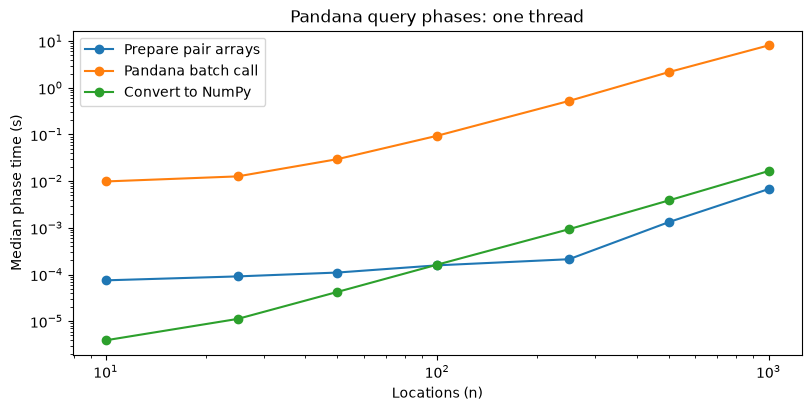

In [22]:
fig, ax = plt.subplots(figsize=(8, 4), layout="constrained")
parts = phase_summary.xs(1, level="threads")
for column, label in [("arrays_s", "Prepare pair arrays"),
                      ("batch_call_s", "Pandana batch call"), ("conversion_s", "Convert to NumPy")]:
    ax.plot(parts.index, parts[column], "o-", label=label)
ax.set(xscale="log", yscale="log", xlabel="Locations (n)", ylabel="Median phase time (s)",
       title="Pandana query phases: one thread")
ax.legend()
plt.show()

## A larger graph: the whole Netherlands

The following **recorded Windows results** were obtained on 24 September 2026,
outside Colab, on an **Intel Core Ultra 9 285HX (24 cores / 24 logical processors),
63.46 GiB RAM, Windows 11 build 26200**, with **Python 3.14.6, Pandana 0.8,
NetworkX 3.6.1, NumPy 2.5.3, pandas 3.0.5, and OSMnx 2.1.1**. They use the
[Geofabrik Netherlands PBF dated 23 September 2026](https://download.geofabrik.de/europe/netherlands-260923.osm.pbf).
The source is OpenStreetMap contributors, ODbL 1.0. The walking graph has
**3,333,231 nodes**, **8,454,986 directed arcs**, and **33,821 connected components**.
We retain the entire graph; seed 2025 selects 1,000 distinct endpoints in the
largest component of **3,143,652 nodes (94.31%)**. All one million selected pairs
are reachable. These are 1,000-by-1,000 matrices on the national graph, not an
all-nodes distance matrix.

The walking filter matches OSMnx's walking filter; arcs are bidirectional, and
ferries and relation turn restrictions are excluded. The streaming PBF builder
retains way endpoints and shared junctions, sums lengths along intermediate
geometry, and keeps the shortest parallel edge. Unlike Amsterdam's OSMnx
simplification, it does not remove degree-two nodes across way boundaries.
Consequently this is **not a controlled graph-size-only comparison**.

For this larger graph as well, we deliberately restrict **Pandana to one thread**
to match the single-threaded NetworkX Dijkstra routine and sequential origin loop,
keeping the focus on the routing implementations rather than parallelism.
NetworkX completed **one cold, single-threaded run**, with no warm-up or restart.
Its query time sums the 1,000 row timings, including Dijkstra, destination
extraction, row-array creation and dictionary cleanup; checkpoint writes,
validation and final matrix assembly are excluded. Pandana was measured in
**three sequential, independent repetitions**. Each repetition started a new
Python process, built its own hierarchy with one OpenMP thread, and performed
one warm-up followed by one measured matrix. Each repetition finished before
the next started; the reported median is not a concurrent multi-process result.
Its query timer includes pair arrays, the public batch call, matrix conversion
and cleanup. Graph loading and preprocessing are excluded for both methods.
NetworkX setup is graph construction; Pandana setup additionally builds the
contraction hierarchy. Pandana setup and query entries are separate medians.
The library runs were not interleaved, and background load was not controlled.

Every result matched an independent SciPy 1.18.1 integer-millimetre Dijkstra
reference to within $10^{-6}$ m; the observed maximum difference was zero.
The reference was generated with four validation workers outside the benchmark
timers. The cells below display these saved measurements; rerunning the notebook
does not download the national PBF or repeat the two-hour NetworkX experiment.

The [archived experiment code and reproduction notes](https://github.com/mobook/MO-book/blob/main/notebooks/04/data/road-benchmark-source/README.md)
identify the exact scripts and original result metadata from this Windows run.
The [Pandana launcher](https://github.com/mobook/MO-book/blob/main/notebooks/04/data/road-benchmark-source/tmp/run-nl-single-thread.py)
executes the repetitions sequentially; its
[worker](https://github.com/mobook/MO-book/blob/main/notebooks/04/data/road-benchmark-source/tmp/nl-thread-worker.py) defines the timing boundaries.
The [NetworkX worker](https://github.com/mobook/MO-book/blob/main/notebooks/04/data/road-benchmark-source/tmp/nl-networkx-background.py)
implements the sequential row-by-row measurement and checkpointing.
The Amsterdam experiment code is included directly in this notebook.


,query_s,min_s,max_s,setup_s,runs
method,,,,,
NetworkX (1 thread),6572.529,6572.529,6572.529,14.882,1
Pandana (1 thread),17.805,17.767,18.275,114.233,3


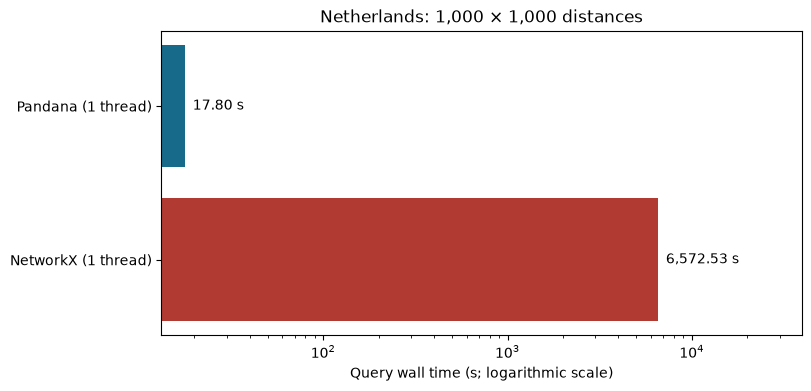

In [23]:
national = pd.DataFrame([{'method': 'NetworkX (1 thread)', 'query_s': 6572.529253199969, 'min_s': 6572.529253199969, 'max_s': 6572.529253199969, 'setup_s': 14.882086199999321, 'runs': 1}, {'method': 'Pandana (1 thread)', 'query_s': 17.8049972000008, 'min_s': 17.766781000000265, 'max_s': 18.27456390000043, 'setup_s': 114.2332279000002, 'runs': 3}]).set_index("method")
display(style_table(national).format({"query_s": "{:.3f}", "min_s": "{:.3f}", "max_s": "{:.3f}", "setup_s": "{:.3f}", "runs": "{:.0f}"}).set_caption("Netherlands: recorded seconds; NetworkX one run, Pandana median of three"))
fig, ax = plt.subplots(figsize=(8, 3.8), layout="constrained")
ax.barh(national.index, national.query_s, color=["#b13b32", "#176a8a"])
ax.set(xscale="log", xlabel="Query wall time (s; logarithmic scale)", title="Netherlands: 1,000 × 1,000 distances")
for i, value in enumerate(national.query_s):
    ax.text(value*1.1, i, f"{value:,.2f} s", va="center")
ax.set_xlim(right=national.query_s.max()*6)
plt.show()

With **one thread for both implementations**, NetworkX took **6,572.53 seconds
(109.54 minutes)** and Pandana took **17.80 seconds**, after preprocessing.
The query-time ratio is approximately **369×**; it describes these runs, not a
confidence interval. Pandana's single-thread preprocessing median was
**114.23 seconds**. This comparison showcases the routing implementations;
Python versus compiled C++ remains an additional source of the difference.

## Save this session's results

This cell packages the current Amsterdam timing records, selected nodes, graph
checksum, graph snapshot, geocoding responses, software and hardware description, plus the already recorded national
table with its separate Windows provenance. It does not claim a new national run.
In Colab it downloads one ZIP file. Download the executed notebook from Colab's
File menu as well, so its plots and outputs are preserved with the measurements.

The [saved local inputs and results](https://raw.githubusercontent.com/mobook/MO-book/main/notebooks/04/data/road-network-recorded-results.zip) accompany the published
Windows execution. New Colab sessions generate their own archive below.


In [24]:

assert environment["run_utc"] and len(timings) == 6 * len(sizes)
assert timings.max_error_m.max() <= 1e-6
session_stamp = environment["run_utc"].replace(":", "").replace("+", "_")
session_folder = evidence / ("session-" + session_stamp)
session_folder.mkdir(exist_ok=True)
timings.to_csv(session_folder / "amsterdam-repetitions.csv", index=False)
summary.to_csv(session_folder / "amsterdam-summary.csv")
phase_summary.to_csv(session_folder / "amsterdam-phases.csv")
np.save(session_folder / "amsterdam-selected.npy", ordered_sample)
national.to_csv(session_folder / "netherlands-recorded-windows.csv")
manifest = {
    "amsterdam_environment": environment,
    "amsterdam_preprocessing_s": setup_times,
    "exported_utc": datetime.now(timezone.utc).isoformat(),
    "validation": {"measured_matrices": len(timings), "max_error_m": float(timings.max_error_m.max())},
    "netherlands_provenance": {"execution": "Previously recorded standalone Windows runs, not this session",
        "date": "2026-09-24", "cpu": "Intel Core Ultra 9 285HX", "physical_cores": 24,
        "logical_processors": 24, "ram_GiB": 63.46, "os": "Windows 11 build 26200",
        "python": "3.14.6", "pandana": "0.8", "networkx": "3.6.1",
        "numpy": "2.5.3", "pandas": "3.0.5", "osmnx": "2.1.1"},
}
(session_folder / "manifest.json").write_text(json.dumps(manifest, indent=2), encoding="utf-8")
archive = evidence / (session_folder.name + ".zip")
with zipfile.ZipFile(archive, "w", compression=zipfile.ZIP_DEFLATED) as bundle:
    for file in sorted(session_folder.iterdir()):
        bundle.write(file, file.name)
    for name in ["amsterdam-walk.graphml.gz", "geocoding.json"]:
        bundle.write(evidence / name, name)
print(f"Saved {len(timings)} validated Amsterdam measurements and their provenance to {archive}")
if IN_COLAB:
    files.download(str(archive))
else:
    display(FileLink(str(archive)))

Saved 42 validated Amsterdam measurements and their provenance to data\shortest-path-live\session-2026-09-24T194338.600132_0000.zip


https://raw.githubusercontent.com/mobook/MO-book/main/notebooks/04/data/road-network-recorded-results.zip

## Why graph size matters most

The most important scalability benefit is handling **much larger road graphs**,
especially for long-distance routes. Dijkstra repeatedly labels nodes across the
reachable graph. Contraction hierarchies add distance-preserving shortcuts during
preprocessing; at query time, forward and backward searches label nodes along
upward edges toward higher-ranked vertices. Long routes can therefore traverse
a much smaller high-level network, skipping most local detail. This progressively
smaller search structure is the sense in which the graph becomes "sparser"; adding
shortcuts need not reduce its stored edge count. See
[Geisberger's description of contraction-hierarchy queries](https://ae.iti.kit.edu/1640.php).

In the recorded Windows experiments, keeping the workload at one million pairs,
the national single-thread query-time ratio is about **369×**. NetworkX's standard
Dijkstra routine is single-threaded; we deliberately limit **Pandana to one
thread** to showcase the algorithmic implementations without parallel speedup.
Language, graph simplification and execution conditions still differ, so this
is not a pure algorithm-only experiment; Colab results must be interpreted on
their own machine.


### From road distances to a traveling salesman tour

The [traveling salesman problem notebook](08-traveling-salesman-problem.ipynb)
shows how to use a matrix of pairwise distances to find a shortest tour visiting
all selected locations and returning to the start. Combining the two notebooks
lets us solve a TSP using real road-network distances: choose the locations,
compute their distance matrix here, and supply it as the cost matrix to a TSP
formulation there instead of using straight-line distances. Keep the same location
ordering for the matrix rows and columns, and choose locations that are mutually
reachable. A directed road network can produce asymmetric distances, so use a
directed TSP formulation unless the matrix is symmetric.
